# 🔬 QuATON-D²NN: Quantization & Noise-Robust Diffractive Optical Neural Networks

## Interactive Workflow Notebook

This notebook provides a comprehensive, step-by-step walkthrough of the entire D²NN pipeline:

1. **Wave Optics Fundamentals** — Angular Spectrum Method, transfer functions
2. **D²NN Architecture** — Layer construction, phase masks, detector design
3. **Quantization Theory** — STE mechanics, bit-width analysis
4. **Training & Evaluation** — Full pipeline with MNIST/Fashion-MNIST
5. **Robustness Benchmarking** — PTQ vs QAT, noise sweeps
6. **Optical Field Visualization** — Wavefront propagation through the network

---

## 0. Setup & Imports

In [2]:
# 1. Clone the repository
!git clone https://github.com/GamageShakthi/quaton-d2nn-prototype.git

# 2. Enter the project directory
%cd quaton-d2nn-prototype

# 3. Install in editable mode
!pip install -e .

Cloning into 'quaton-d2nn-prototype'...
remote: Enumerating objects: 56, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 56 (delta 0), reused 56 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (56/56), 51.56 KiB | 12.89 MiB/s, done.
/content/quaton-d2nn-prototype
Obtaining file:///content/quaton-d2nn-prototype
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for quaton-d2nn (pyproject.toml) ... done
  Created wheel for quaton-d2nn: filename=quaton_d2nn-0.1.0-0.editable-py3-none-any.whl size=7002 sha256=159fa43bb7a8ee48e9600981aac1196cf6c1a8a7ea4d15ff16afd770aaf229e8
  Stored in directory: /tmp/pip-ephem-wheel-cache-e_ta5n83/wheels/e6/77/cb/3d9ed9cc447e32c3e91b2ef0f1c699d9e97262a496b3fc349b
Successfully built quaton-d2nn


In [3]:
import sys
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. Add project root to path BEFORE importing local modules
sys.path.insert(0, os.path.abspath('..'))

# 2. Import local project modules
import d2nn
from d2nn.physics import angular_spectrum_propagate, create_spatial_grid, create_frequency_grid, validate_sampling
from d2nn.physics.diffraction import _build_asm_transfer_function
from d2nn.quantization import uniform_phase_quantize, PhaseQuantizer, StraightThroughEstimator
from d2nn.noise import AlignmentJitter, FabricationNoise, DetectorNoise
from d2nn.layers import AmplitudeEncoder, DiffractiveLayer, PropagationLayer, DetectorLayer
from d2nn.models import D2NNClassifier
from d2nn.training import get_dataloader, Trainer
from d2nn.training.evaluate import evaluate_model, evaluate_ptq_sweep, evaluate_noise_robustness
from d2nn.visualization import (
    plot_phase_masks, plot_wavefield_propagation, plot_detector_energy,
    plot_training_history, plot_quantization_comparison, plot_noise_robustness
)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.11.0+cu128


---
## 1. Wave Optics Fundamentals

### 1.1 The Angular Spectrum Method (ASM)

The ASM provides an **exact solution** to the scalar Helmholtz equation for free-space coherent propagation between parallel planes:

$$U(x,y;z) = \mathcal{F}^{-1}\left\{ \mathcal{F}\{U(x,y;0)\} \cdot H(f_x, f_y; z) \right\}$$

where the **transfer function** is:

$$H(f_x, f_y; z) = \exp\left(j \frac{2\pi}{\lambda} z \sqrt{1 - (\lambda f_x)^2 - (\lambda f_y)^2}\right)$$

for propagating waves ($f_x^2 + f_y^2 \le 1/\lambda^2$), and $H = 0$ for evanescent waves.

Let's visualize the ASM transfer function and demonstrate wave propagation.

In [4]:
# Optical parameters (THz regime — common for D²NN experiments)
N_PIXELS = 64          # Grid size
PIXEL_PITCH = 0.4e-3   # 0.4 mm pixel spacing
WAVELENGTH = 0.75e-3   # 0.75 mm wavelength (400 GHz)
Z = 25e-3              # 25 mm propagation distance

# Validate sampling
sampling = validate_sampling(N_PIXELS, PIXEL_PITCH, WAVELENGTH, Z)
print("Sampling Validation:")
for k, v in sampling.items():
    print(f"  {k}: {v}")

Sampling Validation:
  fresnel_number: 8.738133333333332
  max_nyquist_freq: 1250.0
  max_propagating_freq: 1333.3333333333333
  critical_pitch: 0.000375
  aperture: 0.0256
  sampling_valid: False


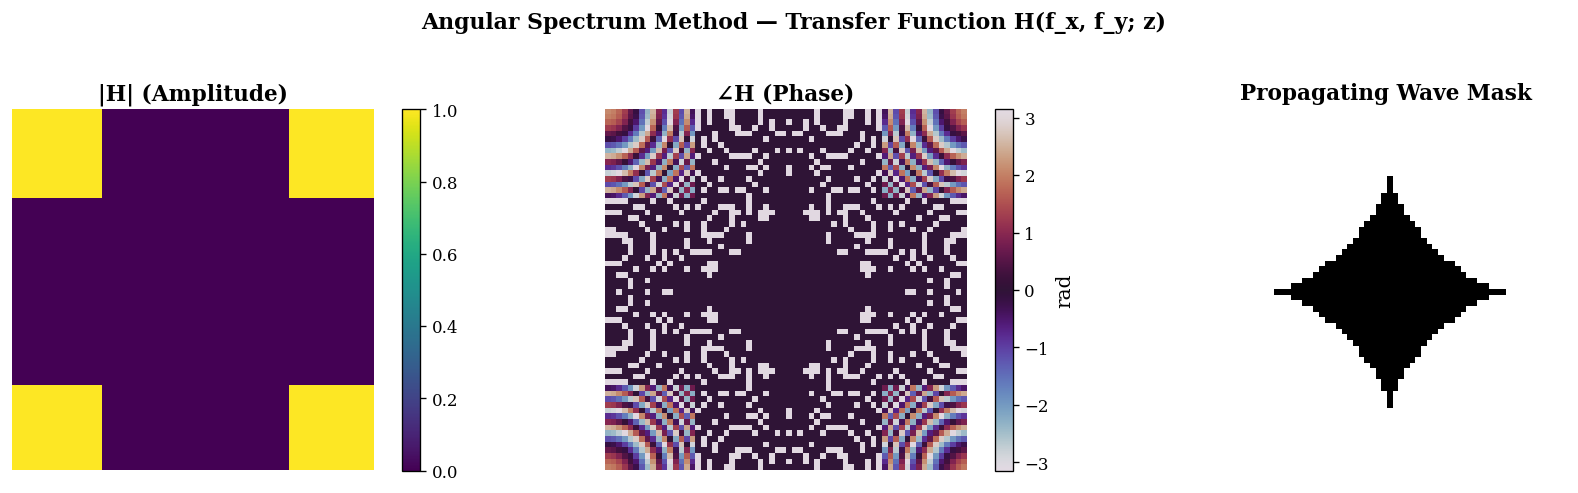

In [5]:
# Visualize the ASM Transfer Function
H = _build_asm_transfer_function(
    n_pixels=N_PIXELS, pixel_pitch=PIXEL_PITCH,
    wavelength=WAVELENGTH, z=Z, bandlimit=True
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Amplitude
im0 = axes[0].imshow(torch.abs(H).numpy(), cmap='viridis', interpolation='nearest')
axes[0].set_title('|H| (Amplitude)', fontweight='bold')
plt.colorbar(im0, ax=axes[0])

# Phase
im1 = axes[1].imshow(torch.angle(H).numpy(), cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes[1].set_title('∠H (Phase)', fontweight='bold')
plt.colorbar(im1, ax=axes[1], label='rad')

# Spatial frequency grid
FX, FY = create_frequency_grid(N_PIXELS, PIXEL_PITCH)
im2 = axes[2].imshow((FX**2 + FY**2 <= (1/WAVELENGTH)**2).float().numpy(),
                      cmap='Greys_r', interpolation='nearest')
axes[2].set_title('Propagating Wave Mask', fontweight='bold')

for ax in axes:
    ax.axis('off')

fig.suptitle('Angular Spectrum Method — Transfer Function H(f_x, f_y; z)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1.2 Diffraction Propagation Demo

Let's propagate a point source (δ-function) and a Gaussian beam to verify the physics.

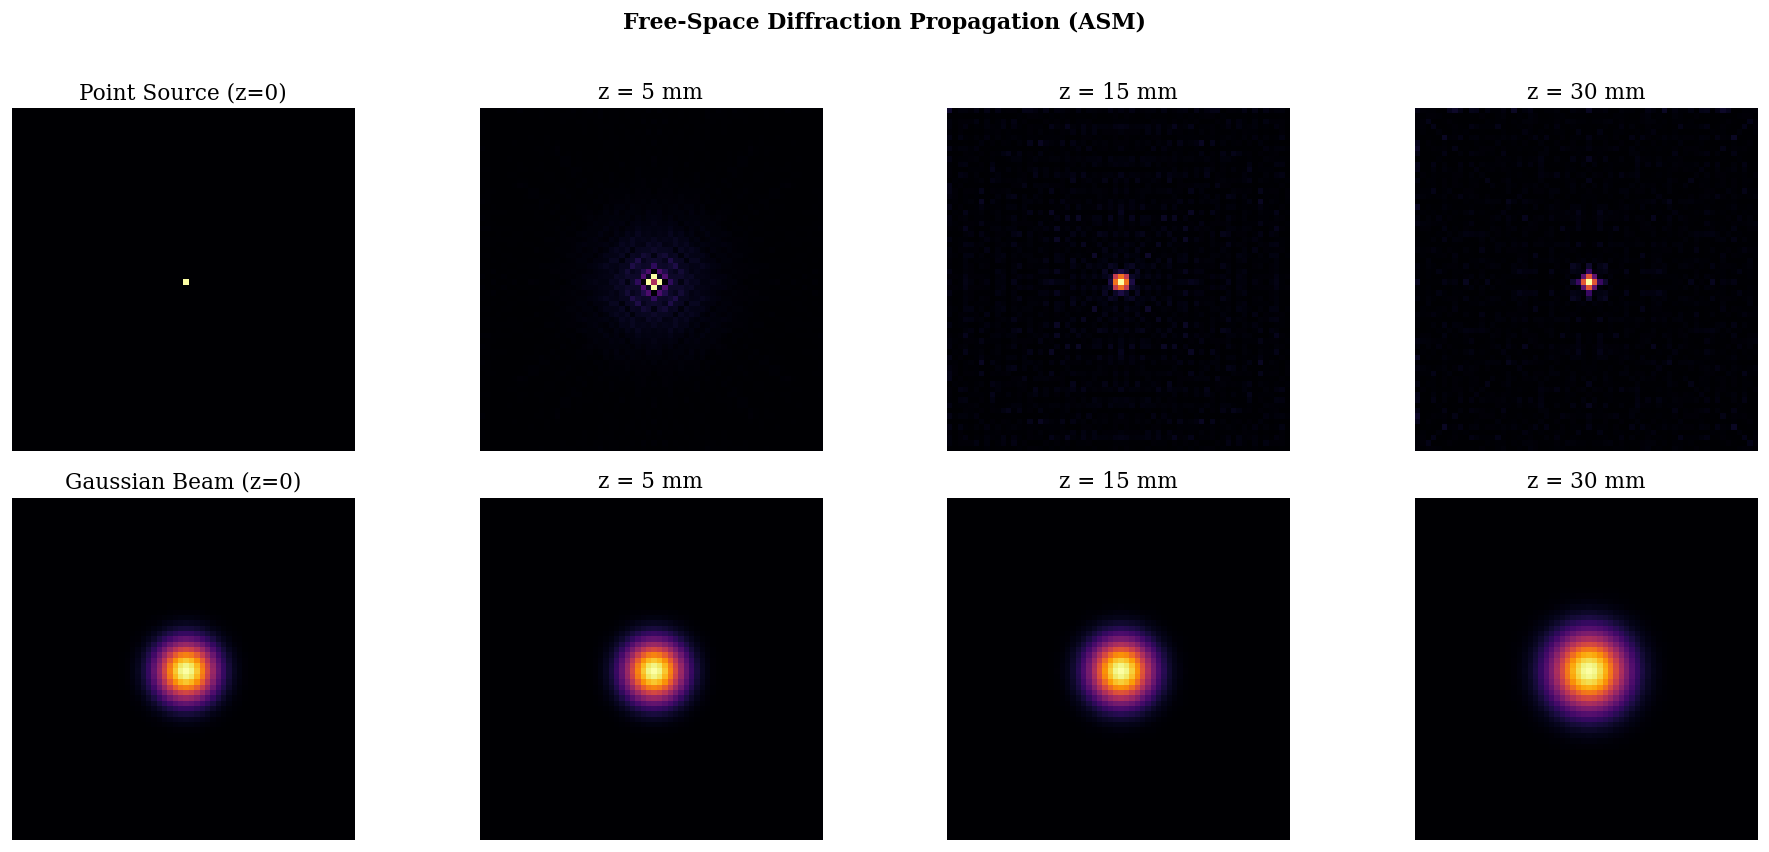

In [6]:
# Create test wavefields
X, Y = create_spatial_grid(N_PIXELS, PIXEL_PITCH)

# 1. Point source (approximately)
u_point = torch.zeros(N_PIXELS, N_PIXELS, dtype=torch.cfloat)
u_point[N_PIXELS//2, N_PIXELS//2] = 1.0 + 0j

# 2. Gaussian beam
w0 = 3e-3  # Beam waist
u_gauss = torch.exp(-(X**2 + Y**2) / w0**2).to(torch.cfloat)

# Propagate at different distances
distances = [5e-3, 15e-3, 30e-3]  # 5mm, 15mm, 30mm

fig, axes = plt.subplots(2, len(distances) + 1, figsize=(16, 7))

# Input fields
axes[0, 0].imshow(torch.abs(u_point).numpy()**2, cmap='inferno')
axes[0, 0].set_title('Point Source (z=0)')
axes[1, 0].imshow(torch.abs(u_gauss).numpy()**2, cmap='inferno')
axes[1, 0].set_title('Gaussian Beam (z=0)')

for i, z in enumerate(distances):
    u_point_z = angular_spectrum_propagate(u_point, PIXEL_PITCH, WAVELENGTH, z, bandlimit=False)
    u_gauss_z = angular_spectrum_propagate(u_gauss, PIXEL_PITCH, WAVELENGTH, z, bandlimit=False)

    axes[0, i+1].imshow(torch.abs(u_point_z).numpy()**2, cmap='inferno')
    axes[0, i+1].set_title(f'z = {z*1000:.0f} mm')

    axes[1, i+1].imshow(torch.abs(u_gauss_z).numpy()**2, cmap='inferno')
    axes[1, i+1].set_title(f'z = {z*1000:.0f} mm')

for ax in axes.flat:
    ax.axis('off')

axes[0, 0].set_ylabel('Point Source', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Gaussian Beam', fontsize=12, fontweight='bold')
fig.suptitle('Free-Space Diffraction Propagation (ASM)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 2. D²NN Architecture

### 2.1 The Diffractive Deep Neural Network

A D²NN consists of:

```
Input Image → Optical Encoder → [Phase Mask → Propagation] × N → Detector → Logits
```

Each diffractive layer applies a **learnable phase modulation**:

$$U_{\text{out}}(x,y) = U_{\text{in}}(x,y) \cdot \exp(j\phi(x,y))$$

where $\phi(x,y)$ are the trainable parameters — analogous to weights in a conventional neural network.

The **detector layer** integrates optical intensity $|U|^2$ over designated spatial regions, one per class.

In [7]:
# Create a D²NN model for MNIST (28×28)
model_demo = D2NNClassifier(
    n_pixels=28,
    n_layers=5,
    n_classes=10,
    pixel_pitch=0.4e-3,
    wavelength=0.75e-3,
    z=25e-3,
    encoding='amplitude',
)

n_params = model_demo.count_optical_parameters()
print(f"Architecture Summary:")
print(f"  Layers: 5 diffractive + 5 propagation")
print(f"  Grid: 28 × 28 pixels")
print(f"  Optical parameters: {n_params:,}")
print(f"  Classes: 10")
print(f"\nModel structure:")
print(model_demo)

Architecture Summary:
  Layers: 5 diffractive + 5 propagation
  Grid: 28 × 28 pixels
  Optical parameters: 3,920
  Classes: 10

Model structure:
D2NNClassifier(
  (encoder): AmplitudeEncoder()
  (optical_layers): ModuleList(
    (0): DiffractiveLayer(
      n_pixels=28, quantizer=PhaseQuantizer(disabled (continuous)), jitter=disabled
      (quantizer): PhaseQuantizer(disabled (continuous))
      (fab_noise): FabricationNoise(phase_sigma=0.0, dead_pixel_prob=0.0, eval_noise=False)
    )
    (1): PropagationLayer(n_pixels=28, pixel_pitch=4.00e-04, wavelength=7.50e-04, z=2.50e-02)
    (2): DiffractiveLayer(
      n_pixels=28, quantizer=PhaseQuantizer(disabled (continuous)), jitter=disabled
      (quantizer): PhaseQuantizer(disabled (continuous))
      (fab_noise): FabricationNoise(phase_sigma=0.0, dead_pixel_prob=0.0, eval_noise=False)
    )
    (3): PropagationLayer(n_pixels=28, pixel_pitch=4.00e-04, wavelength=7.50e-04, z=2.50e-02)
    (4): DiffractiveLayer(
      n_pixels=28, quantizer

Random phase masks before training:


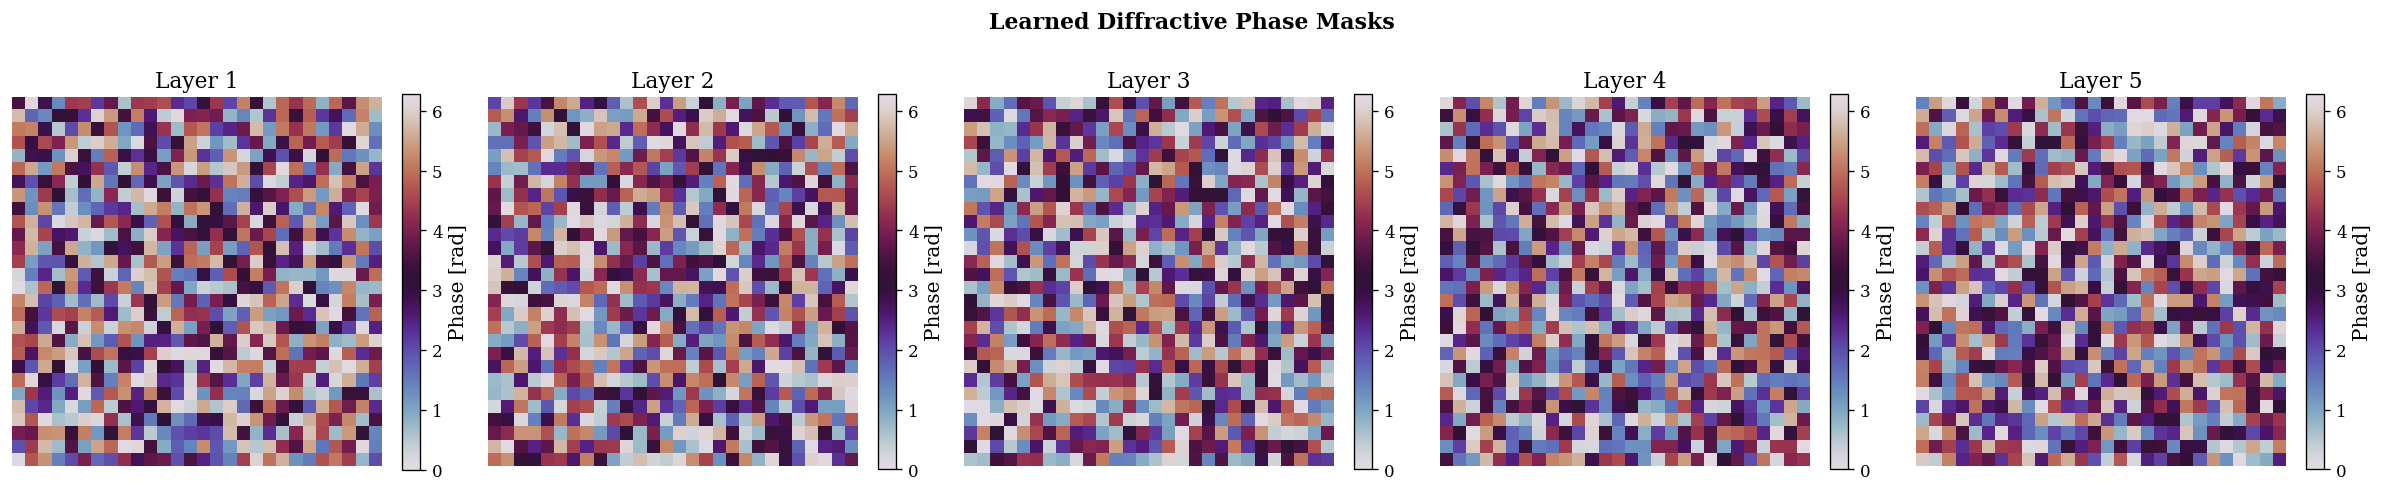

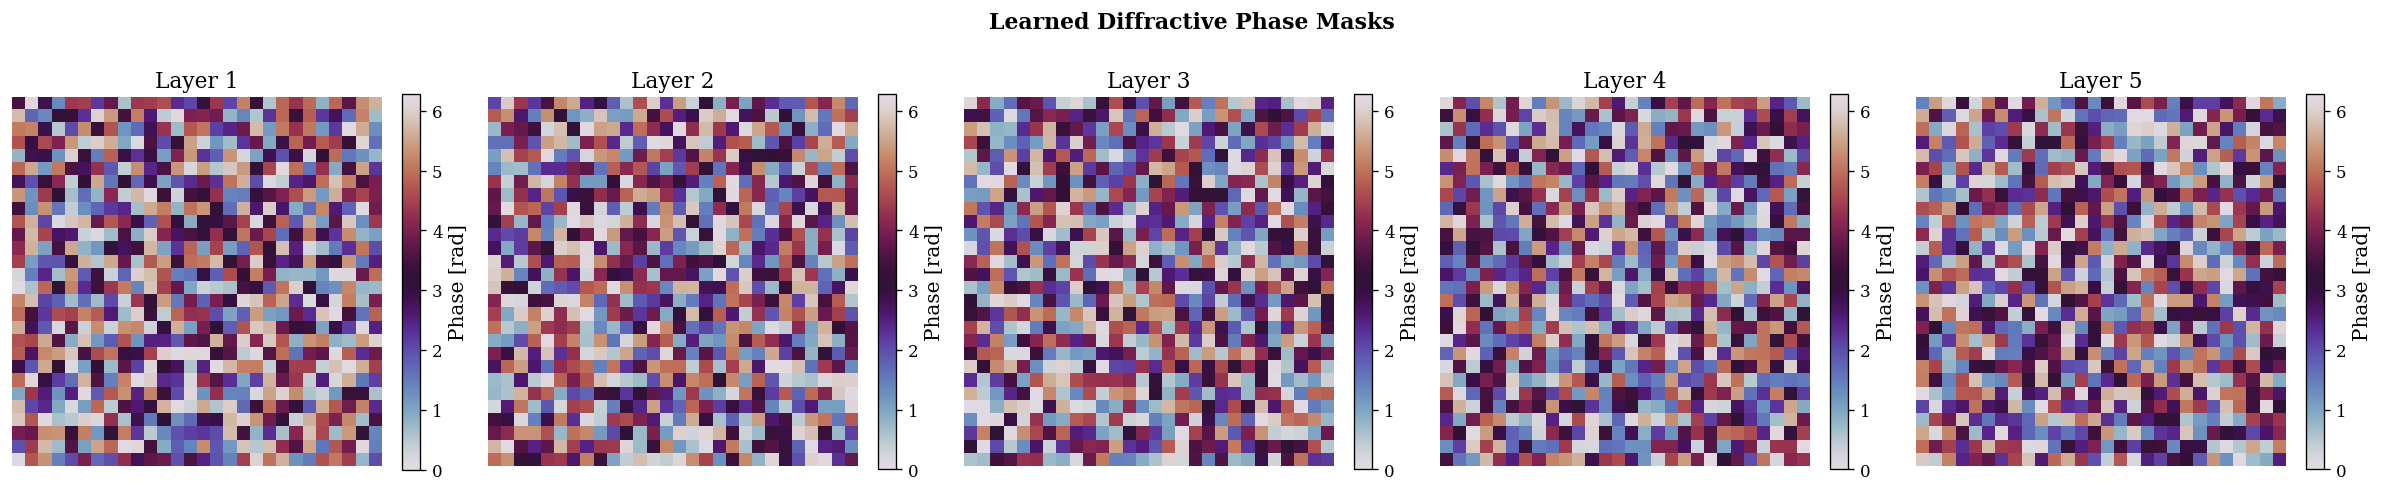

In [8]:
# Visualize initial (random) phase masks
print("Random phase masks before training:")
plot_phase_masks(model_demo.get_phase_masks(), show=True)

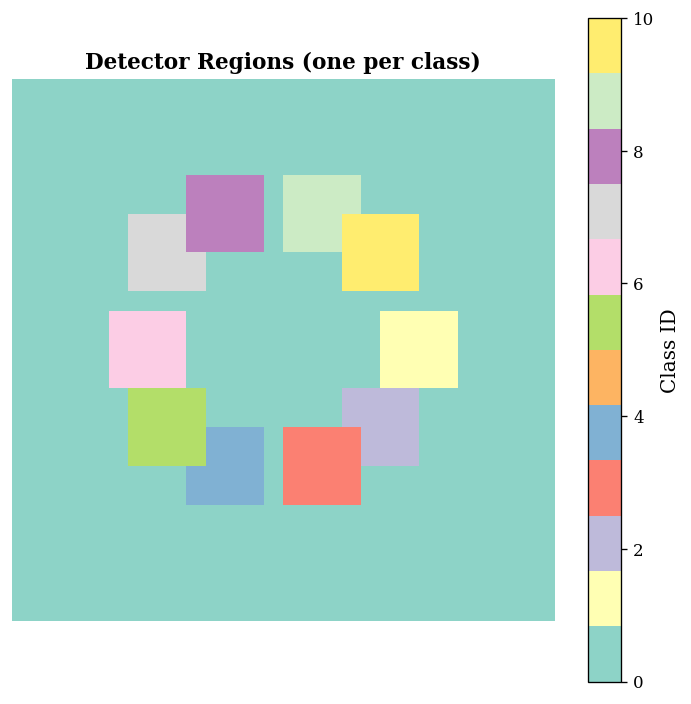

Detector region assignments:
  Class 0: rows [12:16], cols [19:23]
  Class 1: rows [16:20], cols [17:21]
  Class 2: rows [18:22], cols [14:18]
  Class 3: rows [18:22], cols [9:13]
  Class 4: rows [16:20], cols [6:10]
  Class 5: rows [12:16], cols [5:9]
  Class 6: rows [7:11], cols [6:10]
  Class 7: rows [5:9], cols [9:13]
  Class 8: rows [5:9], cols [14:18]
  Class 9: rows [7:11], cols [17:21]


In [9]:
# Visualize detector regions
det_mask = model_demo.detector.get_detector_mask()

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
im = ax.imshow(det_mask.numpy(), cmap='Set3', interpolation='nearest')
ax.set_title('Detector Regions (one per class)', fontweight='bold')
plt.colorbar(im, ax=ax, label='Class ID')
ax.axis('off')
plt.tight_layout()
plt.show()

print("Detector region assignments:")
for c in range(10):
    r0, r1, c0, c1 = model_demo.detector.detector_regions[c].numpy()
    print(f"  Class {c}: rows [{r0}:{r1}], cols [{c0}:{c1}]")

---
## 3. Phase Quantization & STE

### 3.1 The Quantization Problem

Real SLMs (Spatial Light Modulators) can only produce a **finite number of phase levels**.
For a $b$-bit SLM:

$$\Delta\phi = \frac{2\pi}{2^b}, \quad \phi_q = \text{round}\left(\frac{\phi}{\Delta\phi}\right) \cdot \Delta\phi$$

| Bit-width | Phase Levels | Resolution |
|-----------|-------------|------------|
| 1-bit | 2 | π |
| 2-bit | 4 | π/2 |
| 3-bit | 8 | π/4 |
| 4-bit | 16 | π/8 |
| 8-bit | 256 | π/128 |

### 3.2 Straight-Through Estimator (STE)

Since quantization is non-differentiable ($\nabla_\phi \text{round}(\phi) = 0$), we use the STE:

- **Forward**: $\phi_q = \text{quantize}(\phi)$ (discrete output)
- **Backward**: $\frac{\partial \mathcal{L}}{\partial \phi} = \frac{\partial \mathcal{L}}{\partial \phi_q}$ (identity gradient)

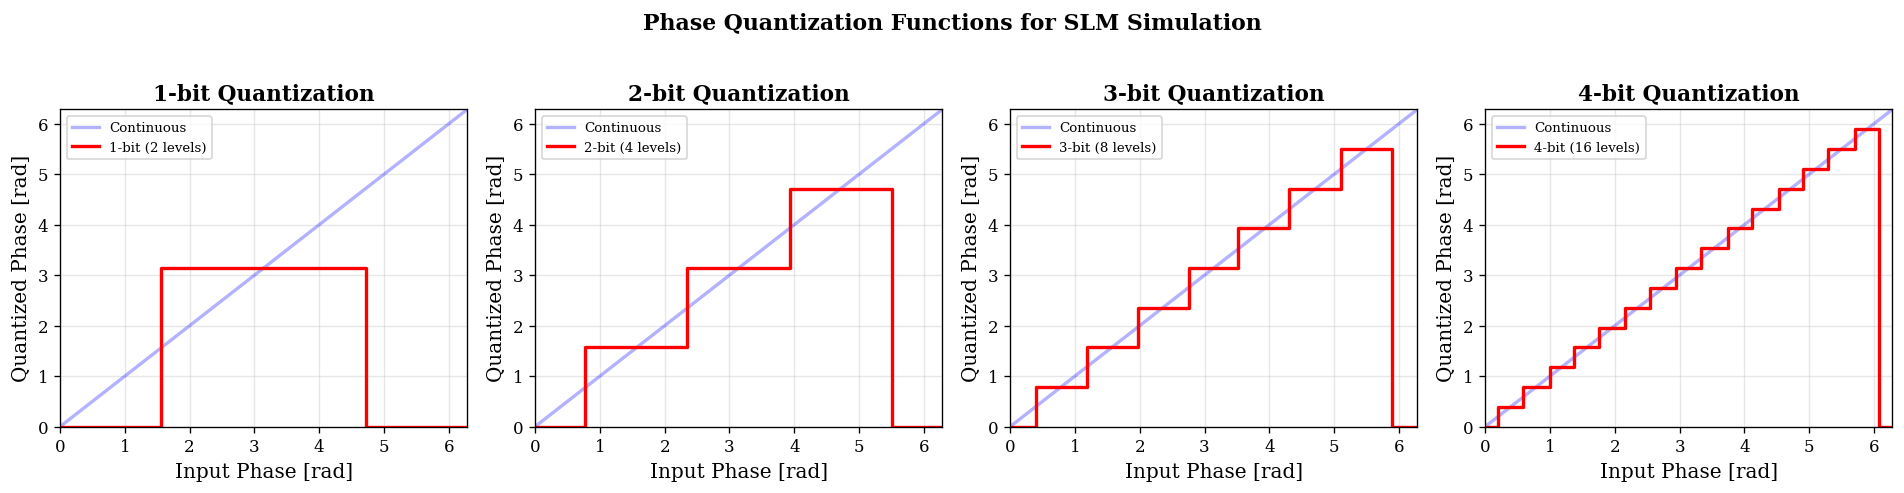

In [10]:
# Visualize quantization at different bit-widths
phi_continuous = torch.linspace(0, 2*math.pi, 200)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, n_bits in zip(axes, [1, 2, 3, 4]):
    phi_q = uniform_phase_quantize(phi_continuous, n_bits)

    ax.plot(phi_continuous.numpy(), phi_continuous.numpy(), 'b-', alpha=0.3,
            label='Continuous', linewidth=2)
    ax.step(phi_continuous.numpy(), phi_q.numpy(), 'r-',
            label=f'{n_bits}-bit ({2**n_bits} levels)', linewidth=2, where='mid')
    ax.set_xlabel('Input Phase [rad]')
    ax.set_ylabel('Quantized Phase [rad]')
    ax.set_title(f'{n_bits}-bit Quantization', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 2*math.pi)
    ax.set_ylim(0, 2*math.pi)

fig.suptitle('Phase Quantization Functions for SLM Simulation', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Demonstrate STE gradient flow
print("=== STE Gradient Flow Demo ===")
print()

# Without STE — round() kills gradients
phi = torch.tensor([0.5, 1.5, 3.0, 5.0], requires_grad=True)
phi_q_naive = torch.round(phi / (math.pi/2)) * (math.pi/2)
loss_naive = phi_q_naive.sum()
loss_naive.backward()
print(f"Naive round() gradient: {phi.grad}")
print(f"  → Gradients are ZERO! Training is impossible.")
print()

# With STE — gradients pass through
phi2 = torch.tensor([0.5, 1.5, 3.0, 5.0], requires_grad=True)
quantizer = PhaseQuantizer(n_bits=2)  # 4 levels
quantizer.train()
phi2_q = quantizer(phi2)
loss_ste = phi2_q.sum()
loss_ste.backward()
print(f"STE quantizer gradient: {phi2.grad}")
print(f"  → Gradients flow! QAT training works.")
print()
print(f"Forward values (quantized): {phi2_q.detach().numpy()}")
print(f"Input values (continuous):  {phi2.detach().numpy()}")

=== STE Gradient Flow Demo ===

Naive round() gradient: tensor([0., 0., 0., 0.])
  → Gradients are ZERO! Training is impossible.

STE quantizer gradient: tensor([1., 1., 1., 1.])
  → Gradients flow! QAT training works.

Forward values (quantized): [0.        1.5707964 3.1415927 4.712389 ]
Input values (continuous):  [0.5 1.5 3.  5. ]


---
## 4. Training & Evaluation

Now let's train a D²NN on MNIST and compare **continuous**, **QAT**, and **PTQ** approaches.

### 4.1 Load Dataset

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.59MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.10MB/s]


Dataset: mnist
Training samples: 60000
Test samples: 10000


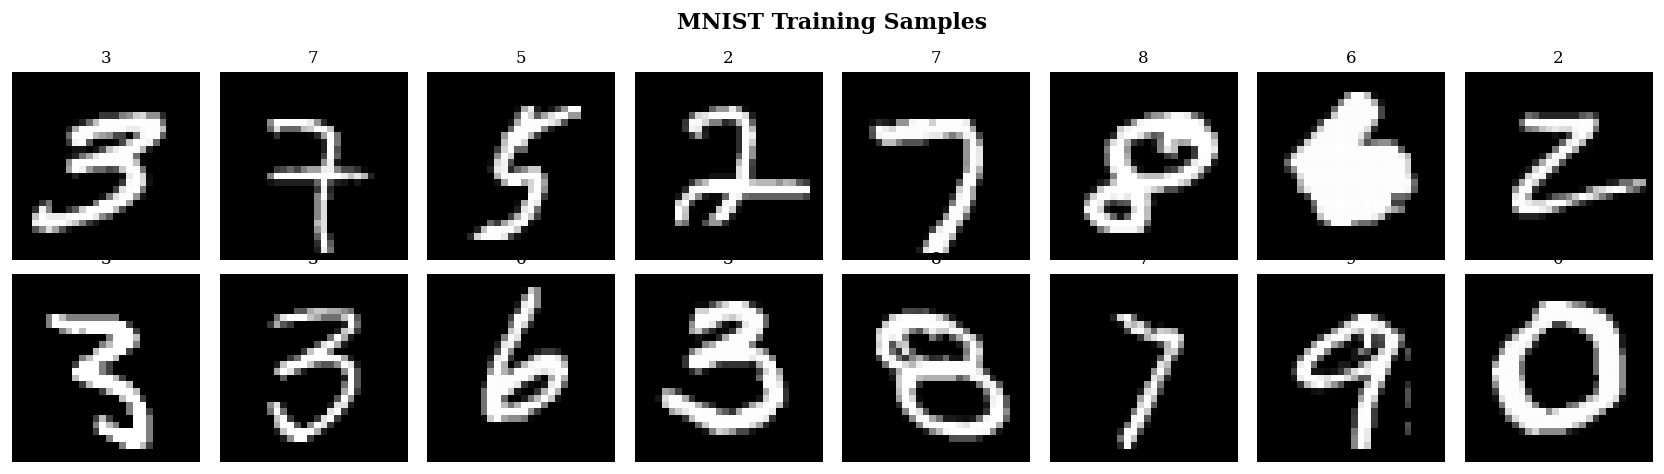

In [12]:
# Load MNIST
DATASET = 'mnist'  # Change to 'fashion_mnist' for Fashion-MNIST
BATCH_SIZE = 64
N_PIXELS = 28

train_loader = get_dataloader(DATASET, train=True, batch_size=BATCH_SIZE, n_pixels=N_PIXELS)
test_loader = get_dataloader(DATASET, train=False, batch_size=128, n_pixels=N_PIXELS)

print(f"Dataset: {DATASET}")
print(f"Training samples: {len(train_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")

# Visualize some samples
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(16):
    ax = axes[i//8, i%8]
    ax.imshow(images[i].squeeze().numpy(), cmap='gray')
    ax.set_title(f'{labels[i].item()}', fontsize=10)
    ax.axis('off')
fig.suptitle(f'{DATASET.upper()} Training Samples', fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Train Continuous (FP32) Model

In [13]:
# --- Training Configuration ---
N_LAYERS = 5
N_EPOCHS = 10  # Increase for better results (20-30 recommended)
LR = 5e-3

# Create continuous (FP32) model
model_fp32 = D2NNClassifier(
    n_pixels=N_PIXELS,
    n_layers=N_LAYERS,
    n_classes=10,
    pixel_pitch=0.4e-3,
    wavelength=0.75e-3,
    z=25e-3,
    n_bits=None,       # ← Continuous (no quantization)
    encoding='amplitude',
)

print(f"Model: Continuous FP32, {N_LAYERS} layers")
print(f"Optical parameters: {model_fp32.count_optical_parameters():,}")
print(f"Training for {N_EPOCHS} epochs...")

# Train
trainer_fp32 = Trainer(model_fp32, device=device, lr=LR,
                       checkpoint_dir='../checkpoints/fp32')
history_fp32 = trainer_fp32.fit(train_loader, test_loader, n_epochs=N_EPOCHS)

Model: Continuous FP32, 5 layers
Optical parameters: 3,920
Training for 10 epochs...


Epoch   1/10 │ Train Loss: 2.1994  Acc: 0.2000 │ Val Loss: 1.2094  Acc: 0.7180 │ LR: 5.00e-03


Epoch   2/10 │ Train Loss: 0.9637  Acc: 0.7961 │ Val Loss: 0.8495  Acc: 0.8275 │ LR: 5.00e-03


Epoch   3/10 │ Train Loss: 0.8748  Acc: 0.8179 │ Val Loss: 0.8149  Acc: 0.8322 │ LR: 4.98e-03


Epoch   4/10 │ Train Loss: 0.8483  Acc: 0.8232 │ Val Loss: 0.7898  Acc: 0.8415 │ LR: 4.96e-03


...

Epoch   6/10 │ Train Loss: 0.8239  Acc: 0.8299 │ Val Loss: 0.7696  Acc: 0.8458 │ LR: 4.88e-03


Epoch   7/10 │ Train Loss: 0.8192  Acc: 0.8325 │ Val Loss: 0.7665  Acc: 0.8465 │ LR: 4.82e-03


Epoch   8/10 │ Train Loss: 0.8164  Acc: 0.8336 │ Val Loss: 0.7634  Acc: 0.8501 │ LR: 4.76e-03


Epoch   9/10 │ Train Loss: 0.8150  Acc: 0.8331 │ Val Loss: 0.7660  Acc: 0.8486 │ LR: 4.69e-03


Epoch  10/10 │ Train Loss: 0.8134  Acc: 0.8339 │ Val Loss: 0.7605  Acc: 0.8515 │ LR: 4.61e-03


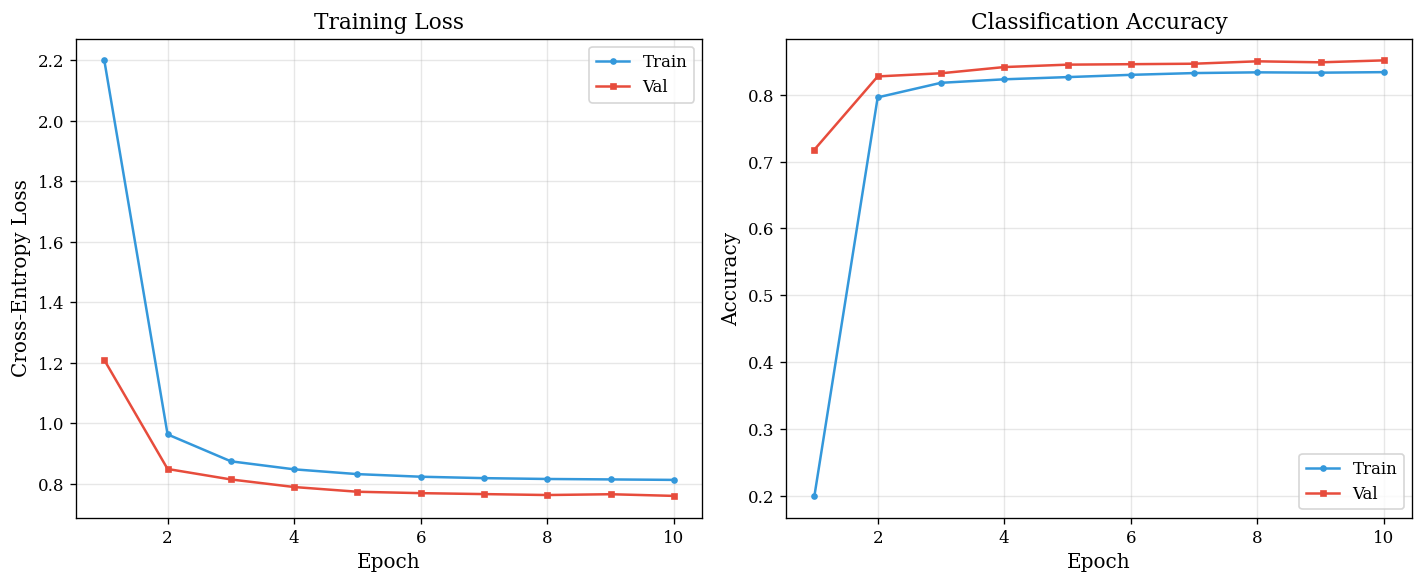

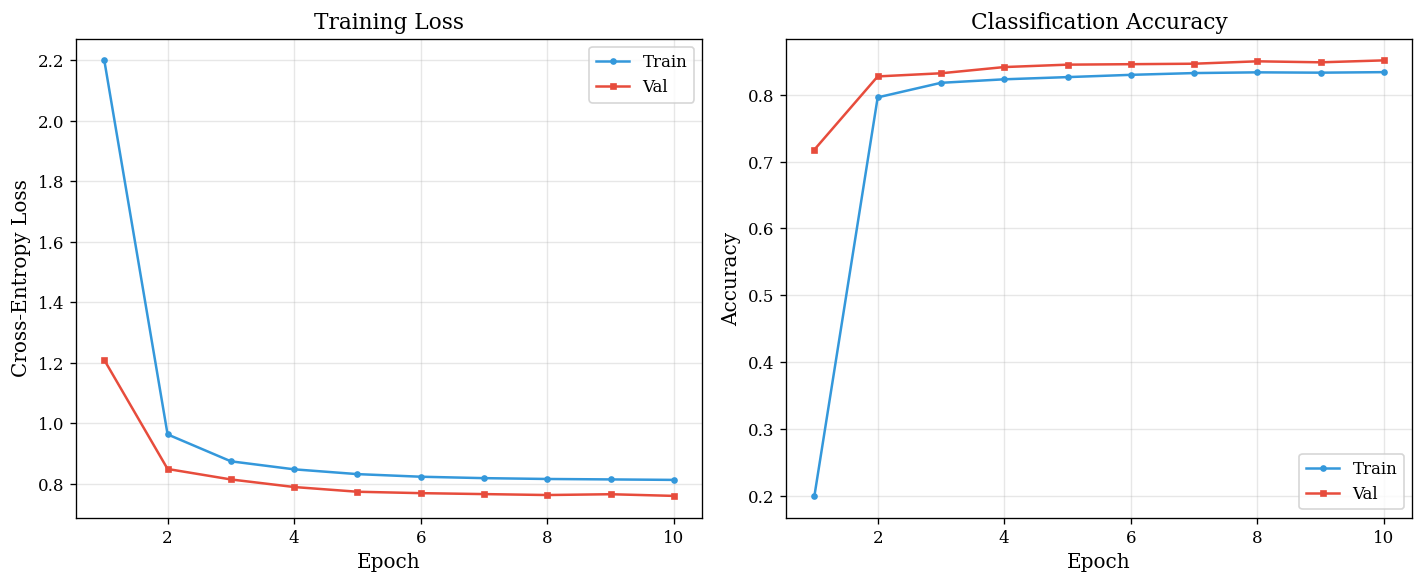

In [14]:
# Plot training curves
plot_training_history(history_fp32, show=True)

### 4.3 Train with 4-bit Quantization-Aware Training (QAT)

In [15]:
# Create 4-bit QAT model
model_qat4 = D2NNClassifier(
    n_pixels=N_PIXELS,
    n_layers=N_LAYERS,
    n_classes=10,
    pixel_pitch=0.4e-3,
    wavelength=0.75e-3,
    z=25e-3,
    n_bits=4,          # ← 4-bit QAT
    encoding='amplitude',
)

print(f"Model: 4-bit QAT, {N_LAYERS} layers")
print(f"Phase levels per pixel: {2**4} = 16")

trainer_qat4 = Trainer(model_qat4, device=device, lr=LR,
                       checkpoint_dir='../checkpoints/qat4')
history_qat4 = trainer_qat4.fit(train_loader, test_loader, n_epochs=N_EPOCHS)

Model: 4-bit QAT, 5 layers
Phase levels per pixel: 16 = 16


Epoch   1/10 │ Train Loss: 2.2101  Acc: 0.1785 │ Val Loss: 1.1142  Acc: 0.7618 │ LR: 5.00e-03


Epoch   2/10 │ Train Loss: 0.9169  Acc: 0.7963 │ Val Loss: 0.8374  Acc: 0.8228 │ LR: 5.00e-03


Epoch   3/10 │ Train Loss: 0.8708  Acc: 0.8029 │ Val Loss: 0.8146  Acc: 0.8277 │ LR: 4.98e-03


Epoch   4/10 │ Train Loss: 0.8722  Acc: 0.8019 │ Val Loss: 0.8199  Acc: 0.8278 │ LR: 4.96e-03


...

Epoch   6/10 │ Train Loss: 0.8735  Acc: 0.7988 │ Val Loss: 0.8518  Acc: 0.7984 │ LR: 4.88e-03


Epoch   7/10 │ Train Loss: 0.8733  Acc: 0.7979 │ Val Loss: 0.8146  Acc: 0.8199 │ LR: 4.82e-03


Epoch   8/10 │ Train Loss: 0.8776  Acc: 0.7952 │ Val Loss: 0.8290  Acc: 0.8192 │ LR: 4.76e-03


Epoch   9/10 │ Train Loss: 0.8761  Acc: 0.7944 │ Val Loss: 0.8094  Acc: 0.8326 │ LR: 4.69e-03


Epoch  10/10 │ Train Loss: 0.8731  Acc: 0.7956 │ Val Loss: 0.8482  Acc: 0.8102 │ LR: 4.61e-03


### 4.4 Train with 2-bit QAT

In [16]:
# Create 2-bit QAT model
model_qat2 = D2NNClassifier(
    n_pixels=N_PIXELS,
    n_layers=N_LAYERS,
    n_classes=10,
    pixel_pitch=0.4e-3,
    wavelength=0.75e-3,
    z=25e-3,
    n_bits=2,          # ← 2-bit QAT (only 4 phase levels!)
    encoding='amplitude',
)

print(f"Model: 2-bit QAT, {N_LAYERS} layers")
print(f"Phase levels per pixel: {2**2} = 4")

trainer_qat2 = Trainer(model_qat2, device=device, lr=LR,
                       checkpoint_dir='../checkpoints/qat2')
history_qat2 = trainer_qat2.fit(train_loader, test_loader, n_epochs=N_EPOCHS)

Model: 2-bit QAT, 5 layers
Phase levels per pixel: 4 = 4


Epoch   1/10 │ Train Loss: 2.3022  Acc: 0.0960 │ Val Loss: 2.2857  Acc: 0.1843 │ LR: 5.00e-03


Epoch   2/10 │ Train Loss: 1.8278  Acc: 0.5276 │ Val Loss: 1.7154  Acc: 0.5721 │ LR: 5.00e-03


Epoch   3/10 │ Train Loss: 1.7541  Acc: 0.5820 │ Val Loss: 1.7131  Acc: 0.6280 │ LR: 4.98e-03


Epoch   4/10 │ Train Loss: 1.7827  Acc: 0.5738 │ Val Loss: 1.7442  Acc: 0.5932 │ LR: 4.96e-03


...

Epoch   6/10 │ Train Loss: 1.7918  Acc: 0.5750 │ Val Loss: 1.7346  Acc: 0.5997 │ LR: 4.88e-03


Epoch   7/10 │ Train Loss: 1.7897  Acc: 0.5795 │ Val Loss: 1.7745  Acc: 0.5245 │ LR: 4.82e-03


Epoch   8/10 │ Train Loss: 1.7926  Acc: 0.5844 │ Val Loss: 1.8133  Acc: 0.6001 │ LR: 4.76e-03


Epoch   9/10 │ Train Loss: 1.7928  Acc: 0.5859 │ Val Loss: 1.8189  Acc: 0.5315 │ LR: 4.69e-03


Epoch  10/10 │ Train Loss: 1.7867  Acc: 0.5909 │ Val Loss: 1.8198  Acc: 0.5280 │ LR: 4.61e-03


### 4.5 Compare Training Curves

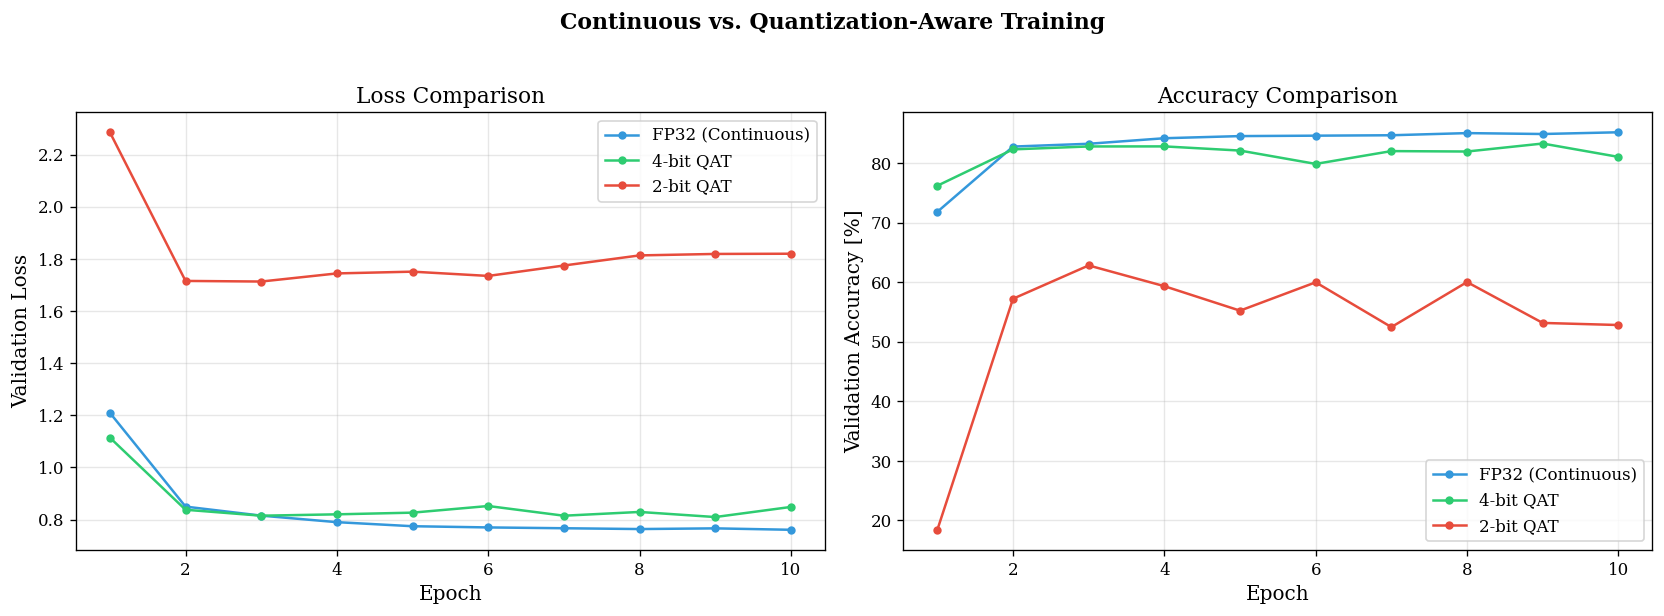

In [17]:
# Compare all training runs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

configs = [
    ('FP32 (Continuous)', history_fp32, '#3498db'),
    ('4-bit QAT', history_qat4, '#2ecc71'),
    ('2-bit QAT', history_qat2, '#e74c3c'),
]

for name, hist, color in configs:
    epochs = range(1, len(hist['val_loss']) + 1)
    ax1.plot(epochs, hist['val_loss'], 'o-', label=name, color=color, markersize=4)
    ax2.plot(epochs, [a*100 for a in hist['val_acc']], 'o-', label=name, color=color, markersize=4)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Validation Loss')
ax1.set_title('Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy [%]')
ax2.set_title('Accuracy Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle('Continuous vs. Quantization-Aware Training', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Robustness Benchmarking

### 5.1 Post-Training Quantization (PTQ) Sweep

Take the **continuously trained FP32 model** and quantize it *after* training at various bit-widths.

In [18]:
# PTQ sweep on the FP32 model
print("=== Post-Training Quantization Sweep ===")
ptq_results = evaluate_ptq_sweep(
    model_fp32, test_loader,
    bit_widths=[1, 2, 3, 4, 8],
    device=device
)

print("\nResults:")
for k, v in ptq_results.items():
    print(f"  {k:>6s}: {v*100:.2f}%")

# Add QAT results for comparison
result_qat4 = evaluate_model(model_qat4, test_loader, device)
result_qat2 = evaluate_model(model_qat2, test_loader, device)

# Combined comparison
comparison = {
    'FP32': ptq_results['fp32'],
    'PTQ-8bit': ptq_results['8bit'],
    'PTQ-4bit': ptq_results['4bit'],
    'QAT-4bit': result_qat4['overall_accuracy'],
    'PTQ-2bit': ptq_results['2bit'],
    'QAT-2bit': result_qat2['overall_accuracy'],
    'PTQ-1bit': ptq_results['1bit'],
}

print("\n=== PTQ vs QAT Comparison ===")
for k, v in comparison.items():
    print(f"  {k:>10s}: {v*100:.2f}%")

=== Post-Training Quantization Sweep ===



Results:
    fp32: 85.15%
    1bit: 23.65%
    2bit: 73.12%
    3bit: 84.62%
    4bit: 85.10%
    8bit: 85.18%



=== PTQ vs QAT Comparison ===
        FP32: 85.15%
    PTQ-8bit: 85.18%
    PTQ-4bit: 85.10%
    QAT-4bit: 81.02%
    PTQ-2bit: 73.12%
    QAT-2bit: 52.80%
    PTQ-1bit: 23.65%


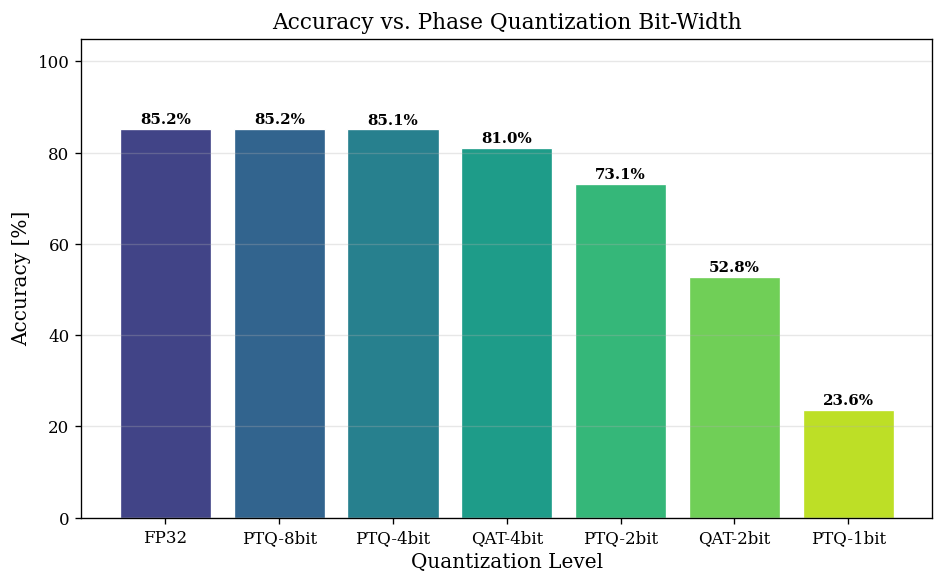

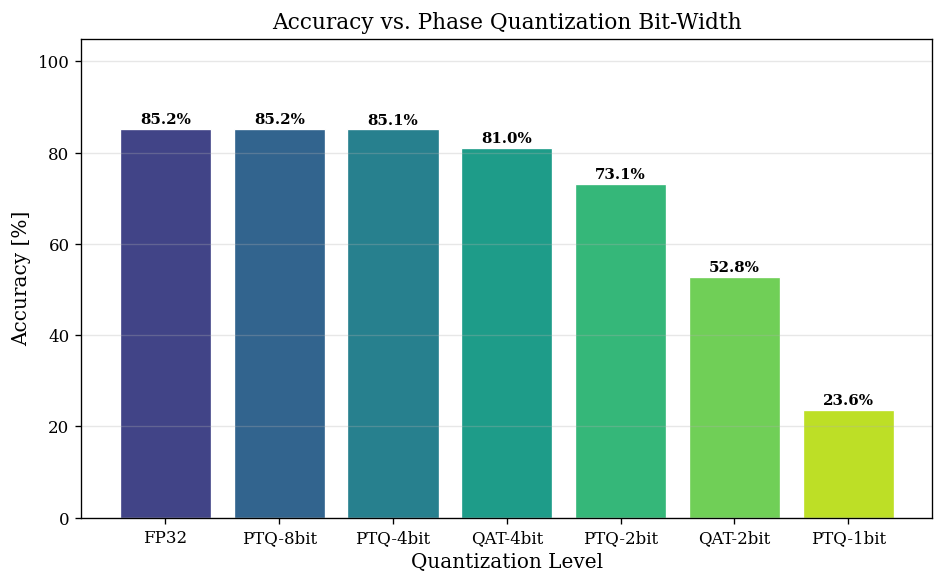

In [19]:
# Visualize PTQ vs QAT comparison
plot_quantization_comparison(comparison, show=True)

### 5.2 Noise Robustness Evaluation

Evaluate how the FP32 model degrades under:
- **Alignment jitter** (lateral misalignment between layers)
- **Fabrication phase noise** (manufacturing errors)

In [20]:
# Noise robustness evaluation (Monte-Carlo)
print("=== Noise Robustness Evaluation ===")
print("(This runs Monte-Carlo trials — may take a few minutes)")

noise_results = evaluate_noise_robustness(
    model_fp32, test_loader,
    jitter_levels=[0.0, 0.25, 0.5, 1.0, 2.0],
    phase_noise_levels=[0.0, 0.05, 0.1, 0.2, 0.5],
    n_trials=3,  # Increase for smoother curves
    device=device
)

print("\nAlignment Jitter:")
for k, v in noise_results['jitter'].items():
    print(f"  σ={k}: {v['mean']*100:.2f}% ± {v['std']*100:.2f}%")

print("\nPhase Noise:")
for k, v in noise_results['phase_noise'].items():
    print(f"  σ={k}: {v['mean']*100:.2f}% ± {v['std']*100:.2f}%")

=== Noise Robustness Evaluation ===
(This runs Monte-Carlo trials — may take a few minutes)



Alignment Jitter:
  σ=0.00: 85.15% ± 0.00%
  σ=0.25: 81.46% ± 0.02%
  σ=0.50: 68.82% ± 0.44%
  σ=1.00: 37.89% ± 0.04%
  σ=2.00: 14.02% ± 0.02%

Phase Noise:
  σ=0.00: 85.15% ± 0.00%
  σ=0.05: 85.11% ± 0.04%
  σ=0.10: 84.97% ± 0.07%
  σ=0.20: 84.56% ± 0.26%
  σ=0.50: 80.54% ± 0.25%


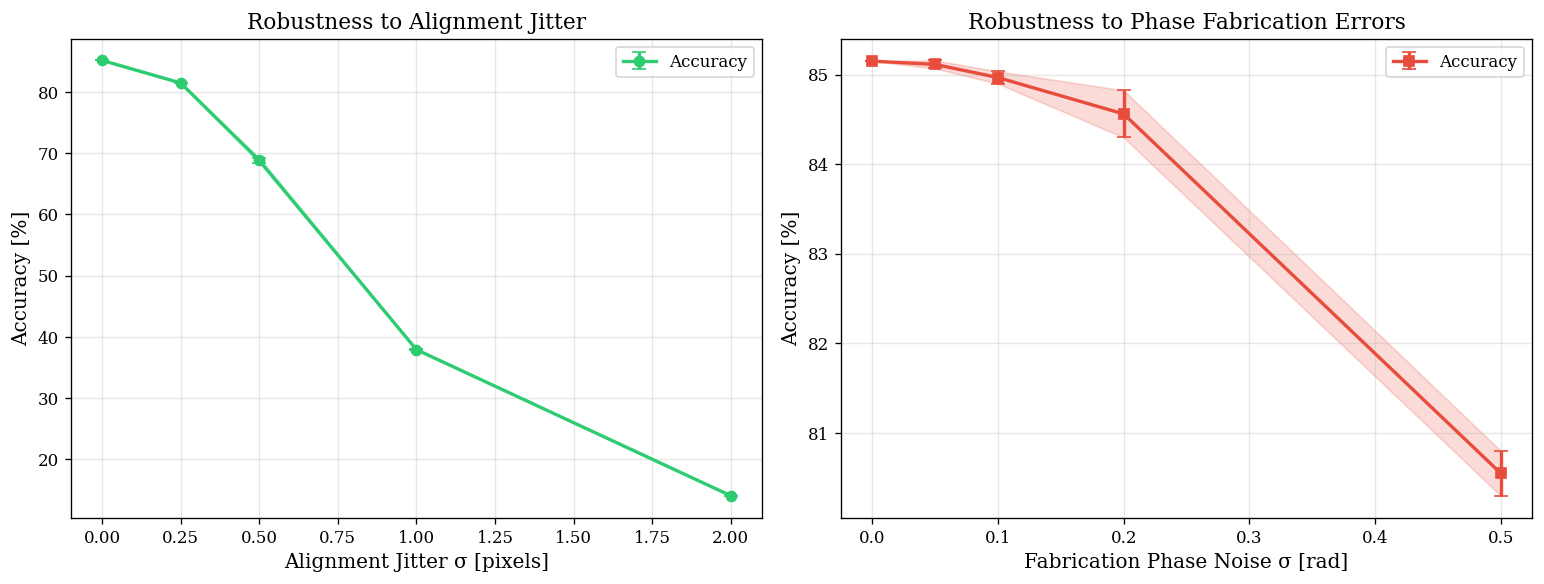

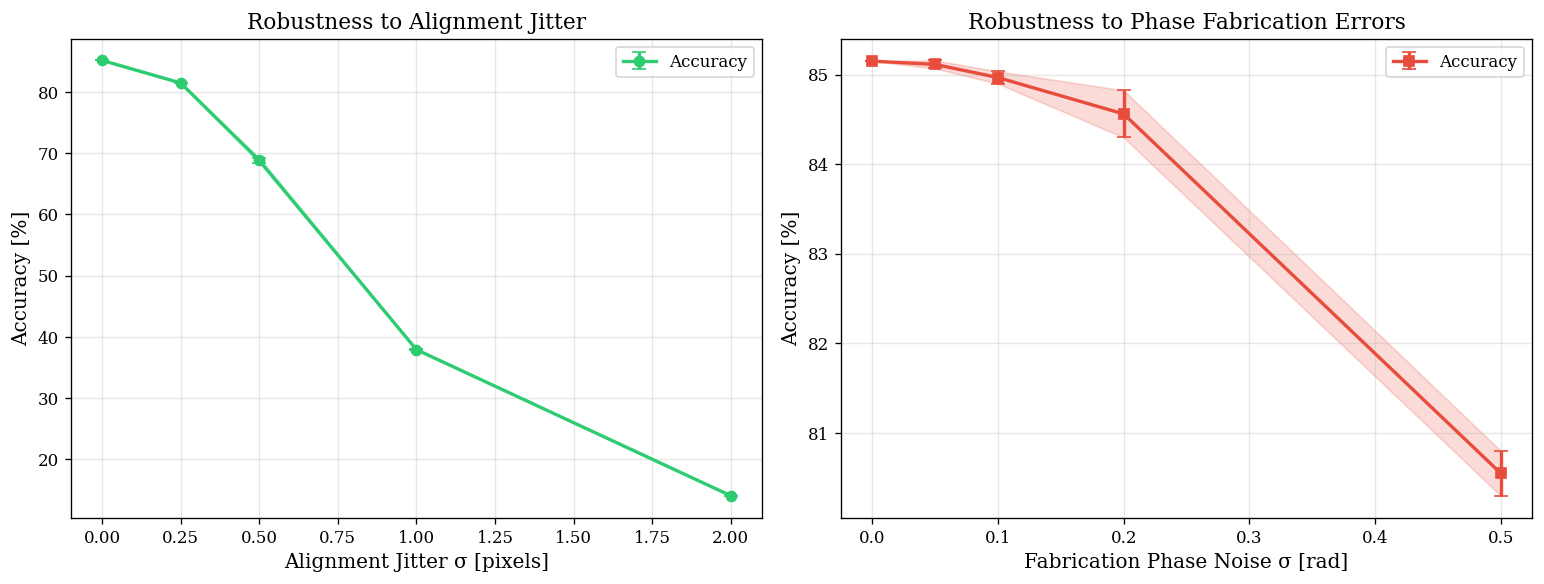

In [21]:
# Visualize noise robustness
plot_noise_robustness(noise_results, show=True)

---
## 6. Optical Field Visualization

### 6.1 Wavefront Propagation Through the Network

Test sample: digit '7'


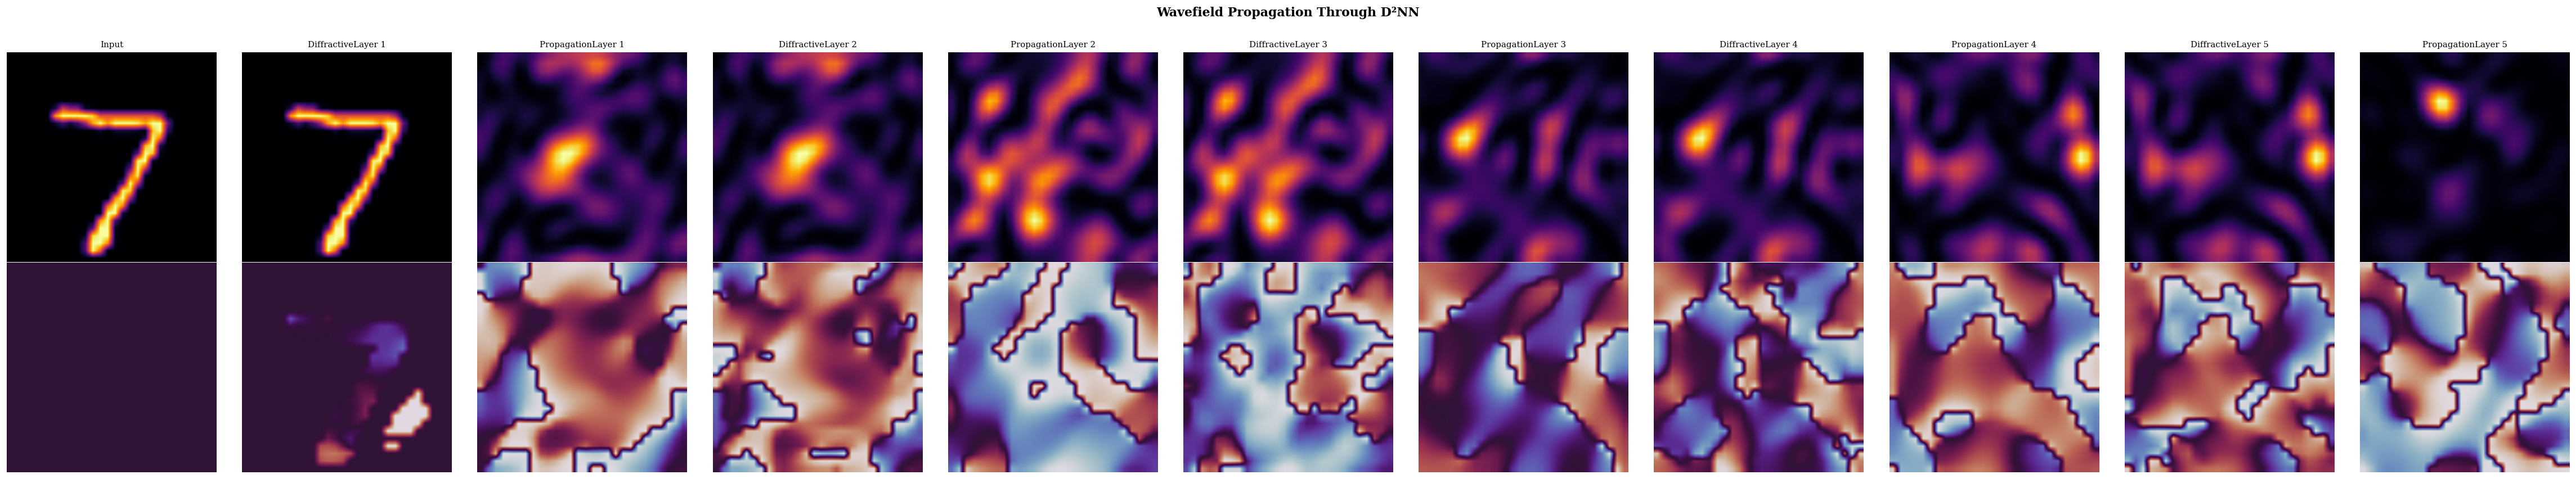

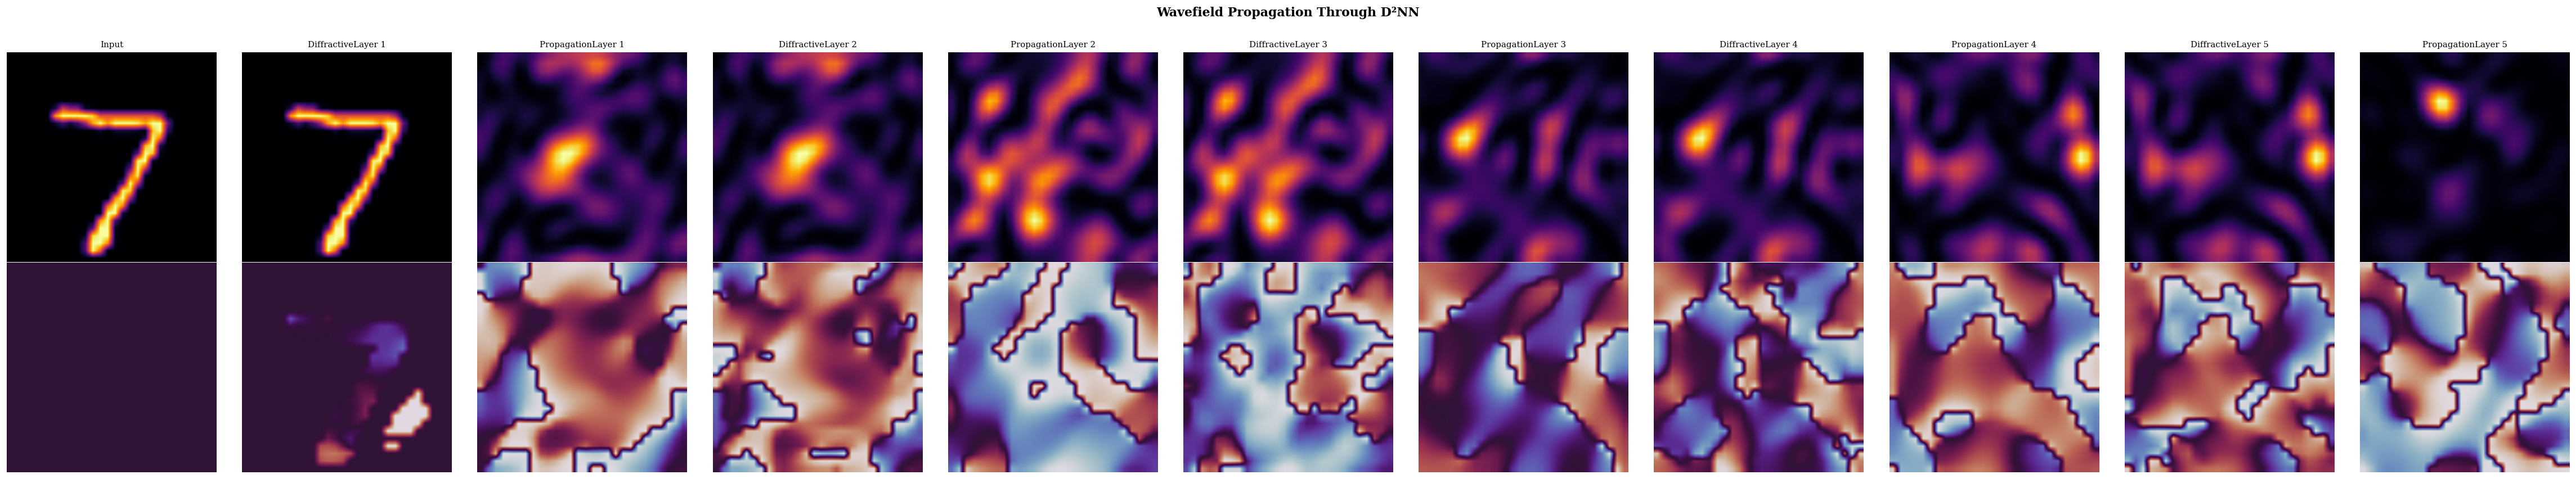

In [22]:
# Visualize wavefield propagation for a single test sample
test_images, test_labels = next(iter(test_loader))
sample_image = test_images[0:1]  # First test image
sample_label = test_labels[0].item()

print(f"Test sample: digit '{sample_label}'")
plot_wavefield_propagation(model_fp32, sample_image, device=device, show=True)

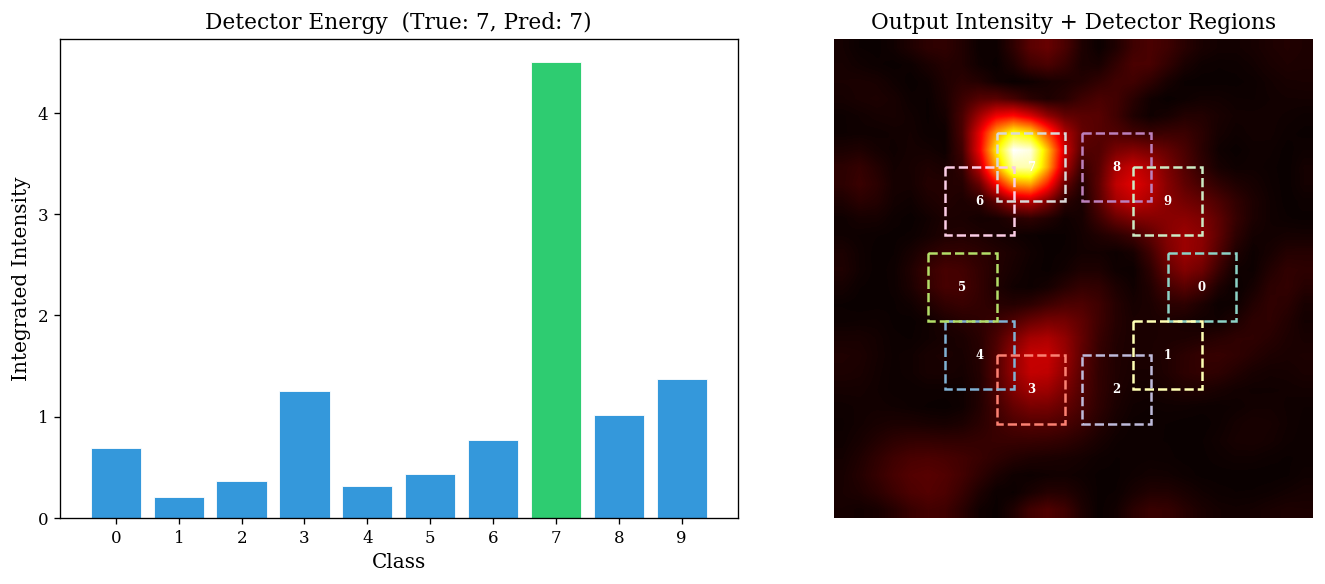

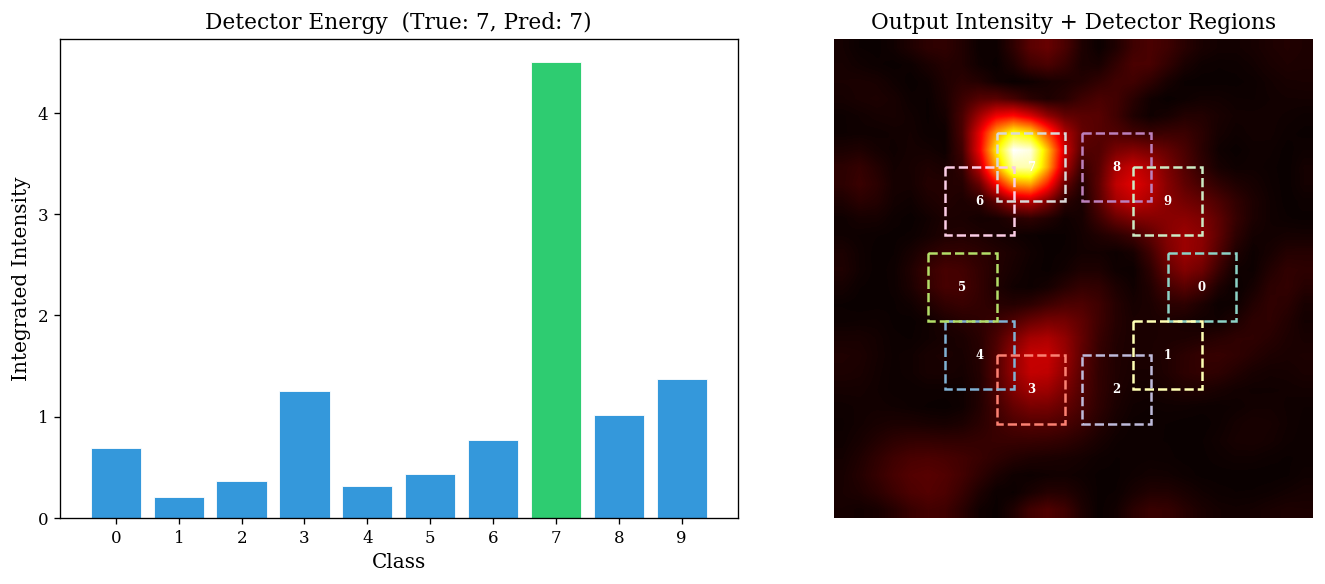

In [23]:
# Detector energy visualization
plot_detector_energy(
    model_fp32, sample_image, label=sample_label,
    device=device, show=True
)

### 6.2 Learned Phase Masks (After Training)

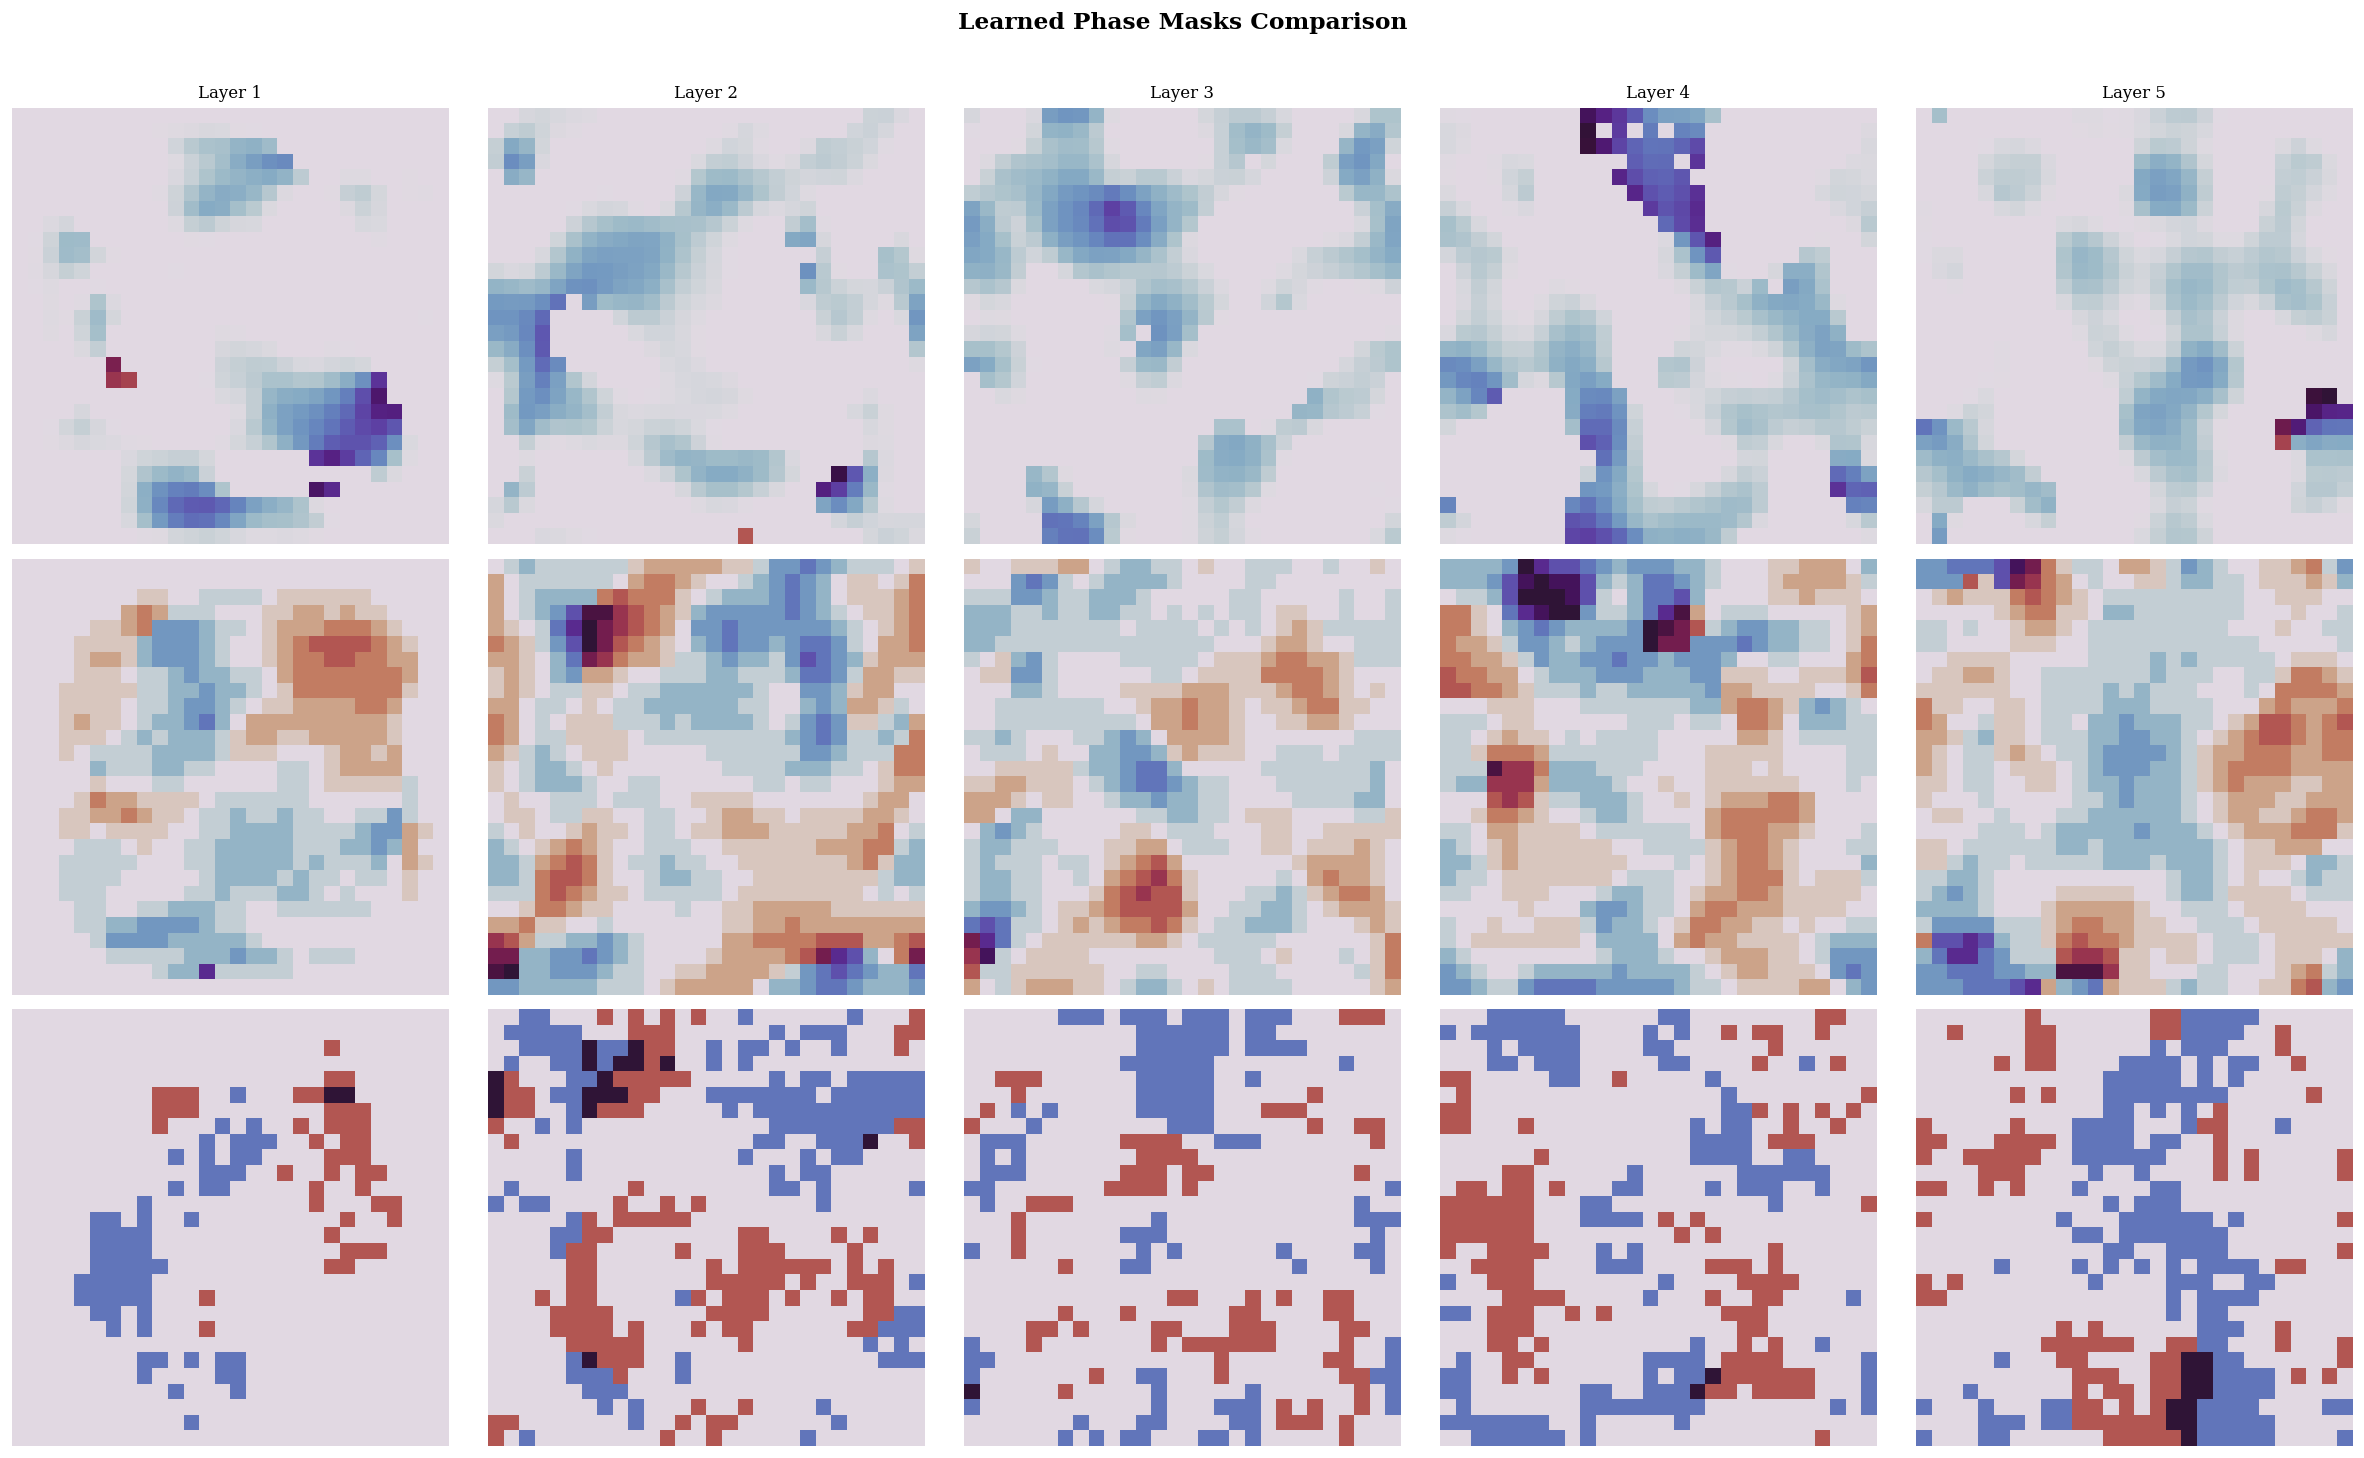

In [25]:
# Compare phase masks: FP32 vs 4-bit QAT vs 2-bit QAT
fig, axes = plt.subplots(3, N_LAYERS, figsize=(4 * N_LAYERS, 12))

models_to_show = [
    ('FP32 Continuous', model_fp32),
    ('4-bit QAT', model_qat4),
    ('2-bit QAT', model_qat2),
]

for row, (name, model) in enumerate(models_to_show):
    masks = model.get_phase_masks()
    for col, mask in enumerate(masks):
        im = axes[row, col].imshow(
            mask.detach().cpu().numpy(), cmap='twilight',
            vmin=0, vmax=2*np.pi, interpolation='nearest'
        )
        if row == 0:
            axes[row, col].set_title(f'Layer {col+1}', fontsize=10)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(name, fontsize=12, fontweight='bold', rotation=90, labelpad=15)

fig.suptitle('Learned Phase Masks Comparison', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Summary & Key Takeaways

### What We've Demonstrated:

1. **Physically-accurate optical simulation** using the Angular Spectrum Method
2. **Quantization-Aware Training (QAT)** via the Straight-Through Estimator maintains performance even at low bit-widths
3. **Post-Training Quantization (PTQ)** causes significant degradation compared to QAT
4. **Noise-robust training** improves resilience to manufacturing imperfections

### Key Insight: QAT vs PTQ

| Method | Approach | Accuracy Retention |
|--------|----------|-------------------|
| **FP32** | Continuous optimization | Baseline |
| **PTQ** | Quantize after training | Degrades significantly at low bits |
| **QAT** | Quantize during training (STE) | Much better retention |
| **Noise-Robust QAT** | QAT + noise injection | Best hardware deployment |

### Next Steps

- Try `fashion_mnist` for a harder classification task
- Increase `n_layers` and `n_epochs` for higher accuracy
- Train with `phase_sigma` and `jitter_sigma` for noise-robust models
- Use `scripts/benchmark_robustness.py` for comprehensive sweeps
- Explore different `pixel_pitch` and `wavelength` configurations

In [26]:
# Final summary
print("=" * 60)
print("  QuATON-D²NN — Experiment Complete")
print("=" * 60)
print(f"\n  FP32 Final Val Accuracy:     {history_fp32['val_acc'][-1]*100:.2f}%")
print(f"  4-bit QAT Final Val Accuracy: {history_qat4['val_acc'][-1]*100:.2f}%")
print(f"  2-bit QAT Final Val Accuracy: {history_qat2['val_acc'][-1]*100:.2f}%")
print(f"\n  GitHub: https://github.com/GamageShakthi/quaton-d2nn")
print("=" * 60)

  QuATON-D²NN — Experiment Complete

  FP32 Final Val Accuracy:     85.15%
  4-bit QAT Final Val Accuracy: 81.02%
  2-bit QAT Final Val Accuracy: 52.80%

  GitHub: https://github.com/GamageShakthi/quaton-d2nn
